In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️ Nota: El árbol CART no requiere StandardScaler — se usa X directamente.")


✅ Librerías importadas correctamente
   pandas   2.2.2
   numpy    1.26.4
   seaborn  0.13.2

⚠️ Nota: El árbol CART no requiere StandardScaler — se usa X directamente.


In [2]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
SQL_QUERY = """
SELECT
    nombre,
    inteligencia,
    fuerza,
    velocidad,
    durabilidad,
    combate,
    promedio_poder,
    ranking,
    CASE
        WHEN promedio_poder >= 70 THEN 1
        ELSE 0
    END AS es_poderoso
FROM superheroes
ORDER BY ranking, nombre;
"""

with engine.connect() as conn:
    df_heroes = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_heroes.shape[0]:,} filas × {df_heroes.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_heroes.columns.tolist()}")

print(f"\nBalance de la variable objetivo:")
bal = df_heroes['es_poderoso'].value_counts()
pct = df_heroes['es_poderoso'].value_counts(normalize=True) * 100

print(f"   Superhéroe poderoso    (1): {bal.get(1, 0):,} ({pct.get(1, 0):.1f}%)")
print(f"   Superhéroe no poderoso (0): {bal.get(0, 0):,} ({pct.get(0, 0):.1f}%)")

df_heroes.head()

✅ Datos cargados: 731 filas × 9 columnas

Columnas disponibles:
['nombre', 'inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'combate', 'promedio_poder', 'ranking', 'es_poderoso']

Balance de la variable objetivo:
   Superhéroe poderoso    (1): 121 (16.6%)
   Superhéroe no poderoso (0): 610 (83.4%)


,nombre,inteligencia,fuerza,velocidad,durabilidad,combate,promedio_poder,ranking,es_poderoso
0,Man of Miracles,100,100,100,100,100,100.00,1.0,1
1,One-Above-All,100,100,100,100,100,100.00,1.0,1
2,General Zod,94,100,96,100,95,97.50,3.0,1
3,Beyonder,100,100,100,100,84,97.33,4.0,1
4,Superboy-Prime,94,100,100,100,85,96.50,5.0,1


In [3]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df_heroes.dtypes.to_frame('dtype').join(
    df_heroes.isnull().sum().to_frame('nulos')
))

# Balance de clases
balance = df_heroes['es_poderoso'].value_counts()
pct = df_heroes['es_poderoso'].value_counts(normalize=True) * 100

print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Superhéroe poderoso    (1): {balance.get(1, 0):>5,} ({pct.get(1, 0):.1f}%)")
print(f"   Superhéroe no poderoso (0): {balance.get(0, 0):>5,} ({pct.get(0, 0):.1f}%)")

print(f"\n🏆 Primeros registros ordenados por ranking:")
print(df_heroes[['nombre', 'promedio_poder', 'ranking', 'es_poderoso']].head(10).to_string(index=False))

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                  dtype  nulos
nombre           object      0
inteligencia      int64      0
fuerza            int64      0
velocidad         int64      0
durabilidad       int64      0
combate           int64      0
promedio_poder  float64      0
ranking         float64      0
es_poderoso       int64      0

🎯 Balance de la variable objetivo:
   Superhéroe poderoso    (1):   121 (16.6%)
   Superhéroe no poderoso (0):   610 (83.4%)

🏆 Primeros registros ordenados por ranking:
           nombre  promedio_poder  ranking  es_poderoso
  Man of Miracles          100.00      1.0            1
    One-Above-All          100.00      1.0            1
      General Zod           97.50      3.0            1
         Beyonder           97.33      4.0            1
   Superboy-Prime           96.50      5.0            1
         Superman           96.50      5.0            1
      Steppenwolf           96.17      7.0            1
Martian Manhu

In [4]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_heroes.copy()

# Variables predictoras tomadas del proyecto de superhéroes
FEATURES = [
    'inteligencia',
    'fuerza',
    'velocidad',
    'durabilidad',
    'combate'
]

# Relleno de nulos con la mediana en variables numéricas
for col in FEATURES:
    df[col] = df[col].fillna(df[col].median())

# Definir X e y — SIN escalado porque CART no lo requiere
X = df[FEATURES]
y = df['es_poderoso']

print("✅ Preprocesamiento completado")
print(f"   Shape X: {X.shape}")
print(f"   Columnas finales: {X.columns.tolist()}")
print(f"\n   Clases en y → 0: {(y==0).sum():,} | 1: {(y==1).sum():,}")
print("\n⚠️ No se aplica StandardScaler — los árboles CART no requieren escalado.")

✅ Preprocesamiento completado
   Shape X: (731, 5)
   Columnas finales: ['inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'combate']

   Clases en y → 0: 610 | 1: 121

⚠️ No se aplica StandardScaler — los árboles CART no requieren escalado.


In [5]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split", max_depth=None):
    """
    Entrena DecisionTreeClassifier con un split train/test y devuelve
    un diccionario con métricas + datos para curva ROC y matriz de confusión.

    Parámetros CART:
      · criterion='gini'          — impureza Gini (CART estándar)
      · class_weight='balanced'   — compensa posible desbalance de clases
      · max_depth                 — None = árbol sin límite de profundidad
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]   # probabilidad clase 1

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'")

✅ Función `entrenar_evaluar` definida correctamente
   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'


In [6]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X, y, test_size=0.30, nombre="Split 70/30"),
]

# Imprimir métricas en consola
print("=" * 75)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART':^75}")
print("=" * 75)

header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 75)

for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )

print("=" * 75)

              MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART               
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
---------------------------------------------------------------------------
Split 80/20       584      147  0.8980  0.6286  0.9167  0.7458  0.9351
Split 60/40       438      293  0.9113  0.6719  0.8958  0.7679  0.9438
Split 70/30       511      220  0.9500  0.7778  0.9722  0.8642  0.9743


🏆 Mejor max_depth según F1-Score (test): 7
   F1-Score test en depth=7: 0.7458


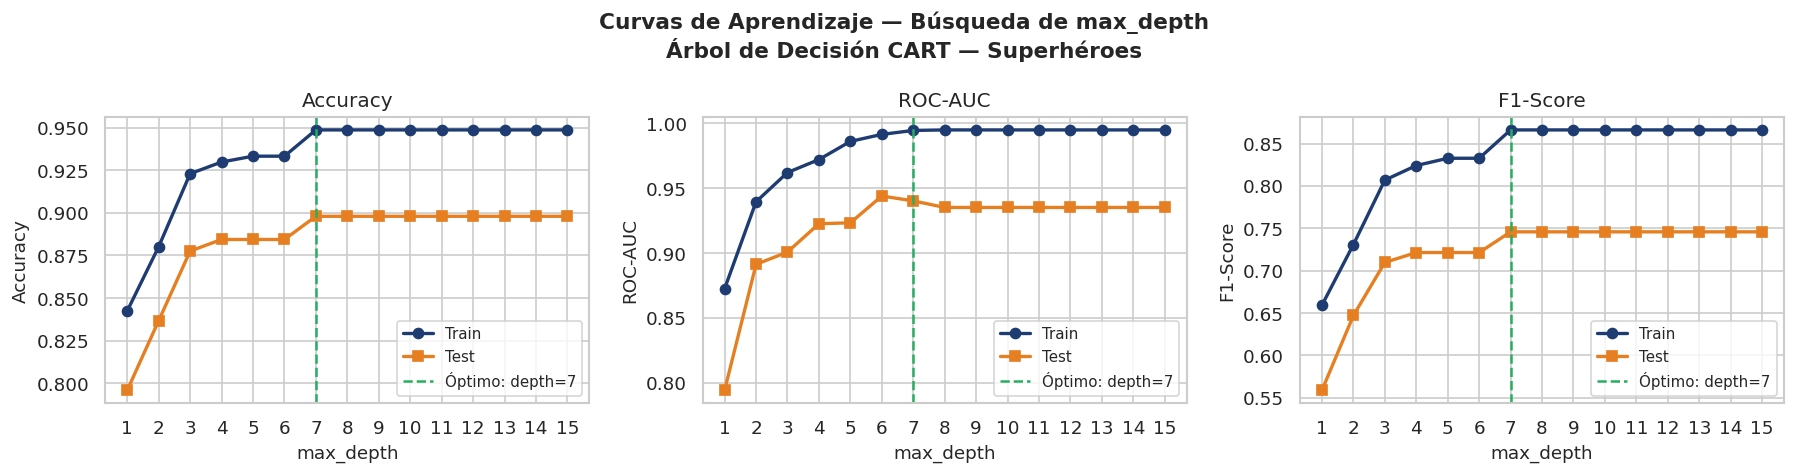

✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_superheroes.png


In [7]:
# ── CELDA 7: Búsqueda de max_depth óptimo ────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

profundidades = range(1, 16)

acc_train, acc_test = [], []
auc_train, auc_test = [], []
f1_train, f1_test = [], []

for d in profundidades:
    m = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )

    m.fit(X_tr, y_tr)

    # Train
    acc_train.append(accuracy_score(y_tr, m.predict(X_tr)))
    auc_train.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))
    f1_train.append(f1_score(y_tr, m.predict(X_tr), zero_division=0))

    # Test
    acc_test.append(accuracy_score(y_te, m.predict(X_te)))
    auc_test.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
    f1_test.append(f1_score(y_te, m.predict(X_te), zero_division=0))

# Mejor max_depth según F1 en test
mejor_depth = list(profundidades)[int(np.argmax(f1_test))]

print(f"🏆 Mejor max_depth según F1-Score (test): {mejor_depth}")
print(f"   F1-Score test en depth={mejor_depth}: {max(f1_test):.4f}")

# Gráfico: curvas de entrenamiento vs prueba
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    'Curvas de Aprendizaje — Búsqueda de max_depth\n'
    'Árbol de Decisión CART — Superhéroes',
    fontsize=13,
    fontweight='bold'
)

metricas_plot = [
    ('Accuracy', acc_train, acc_test),
    ('ROC-AUC', auc_train, auc_test),
    ('F1-Score', f1_train, f1_test),
]

for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):
    ax.plot(profundidades, train_vals, 'o-', color='#1e3c72', lw=2, label='Train')
    ax.plot(profundidades, test_vals, 's-', color='#e67e22', lw=2, label='Test')
    ax.axvline(
        x=mejor_depth,
        color='#27ae60',
        linestyle='--',
        lw=1.5,
        label=f'Óptimo: depth={mejor_depth}'
    )
    ax.set_xlabel('max_depth', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.savefig('../data/graficas/max_depth_arbol_superheroes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_superheroes.png")

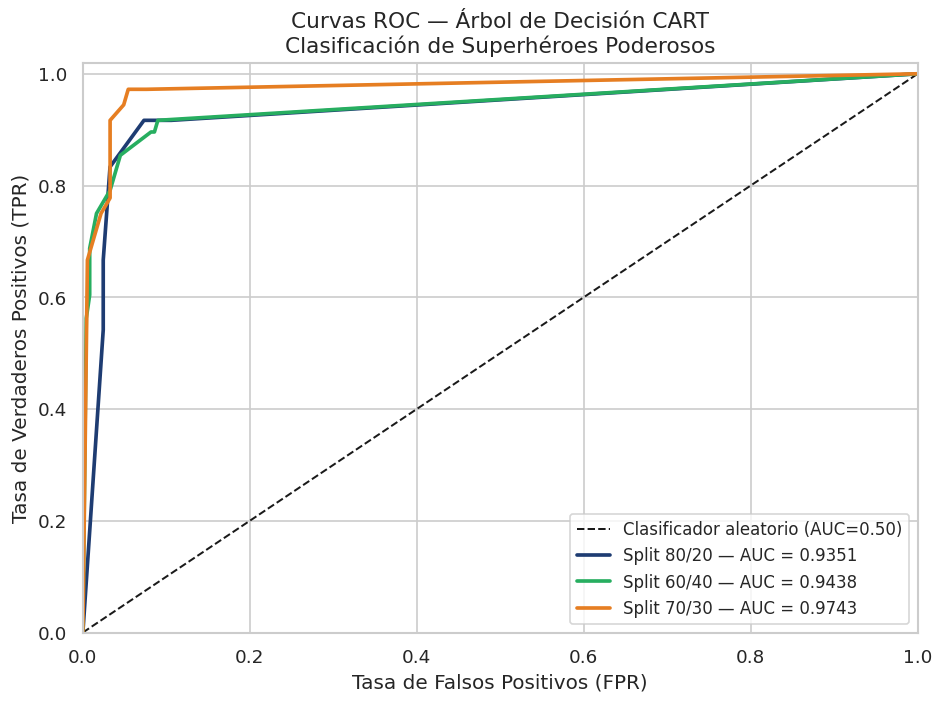

✅ Curvas ROC guardadas en data/graficas/roc_arbol_superheroes.png


In [8]:
# ── CELDA 8: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1.2,
    label='Clasificador aleatorio (AUC=0.50)'
)

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'],
        r['tpr'],
        color=color,
        lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title(
    'Curvas ROC — Árbol de Decisión CART\n'
    'Clasificación de Superhéroes Poderosos',
    fontsize=13
)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../data/graficas/roc_arbol_superheroes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Curvas ROC guardadas en data/graficas/roc_arbol_superheroes.png")

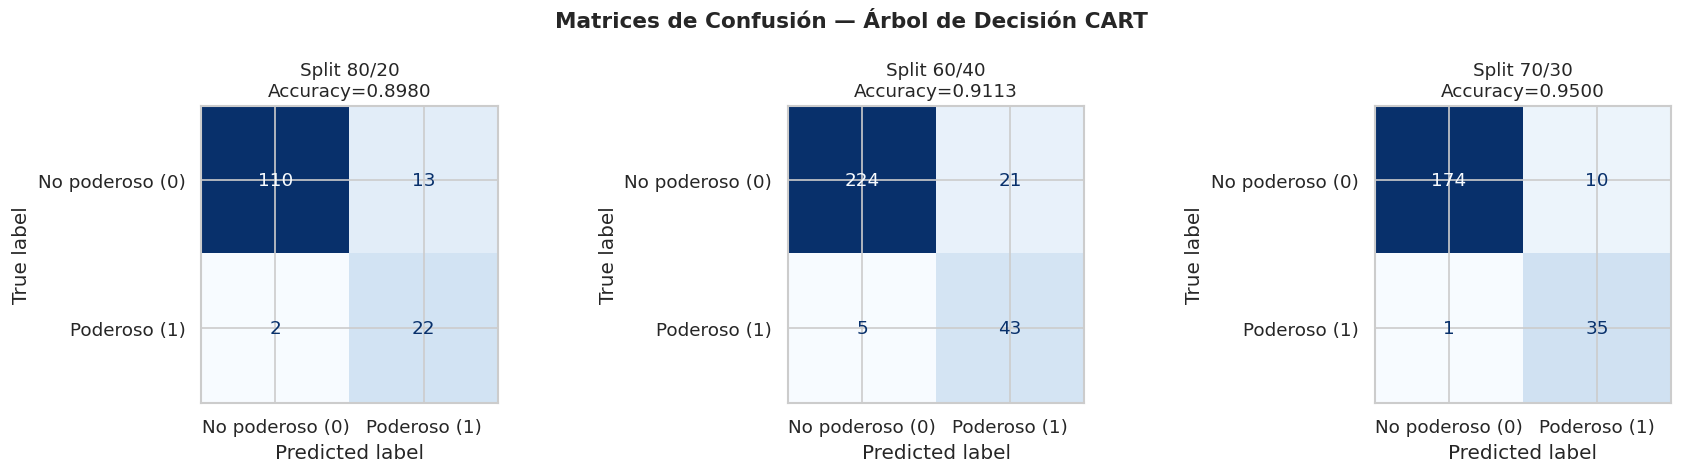

✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_superheroes.png


In [9]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(
    'Matrices de Confusión — Árbol de Decisión CART',
    fontsize=13,
    fontweight='bold'
)

for ax, r, color in zip(axes, resultados, COLORS):
    cm = confusion_matrix(r['y_test'], r['y_pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No poderoso (0)', 'Poderoso (1)']
    )

    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_title(
        f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}",
        fontsize=11
    )

plt.tight_layout()
plt.savefig('../data/graficas/confusion_arbol_superheroes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_superheroes.png")

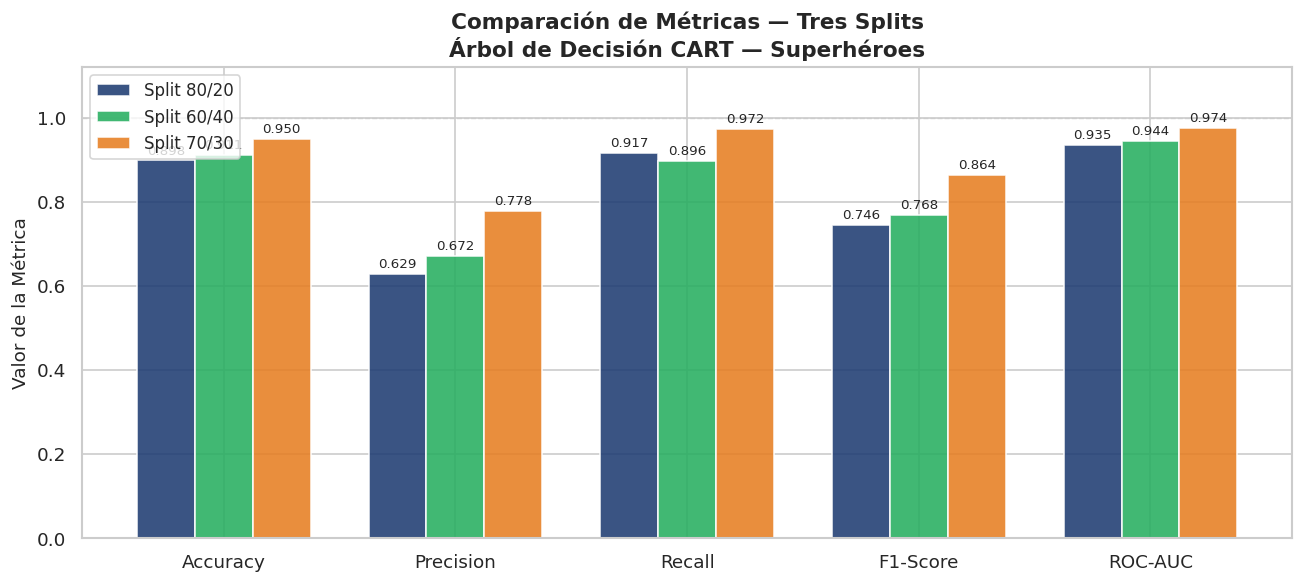

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_superheroes.png


In [10]:
# ── CELDA 10: Gráfico comparativo de métricas ────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=r['nombre'],
        color=color,
        alpha=0.88
    )

    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)

ax.set_title(
    'Comparación de Métricas — Tres Splits\n'
    'Árbol de Decisión CART — Superhéroes',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../data/graficas/metricas_comparativas_arbol_superheroes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_superheroes.png")

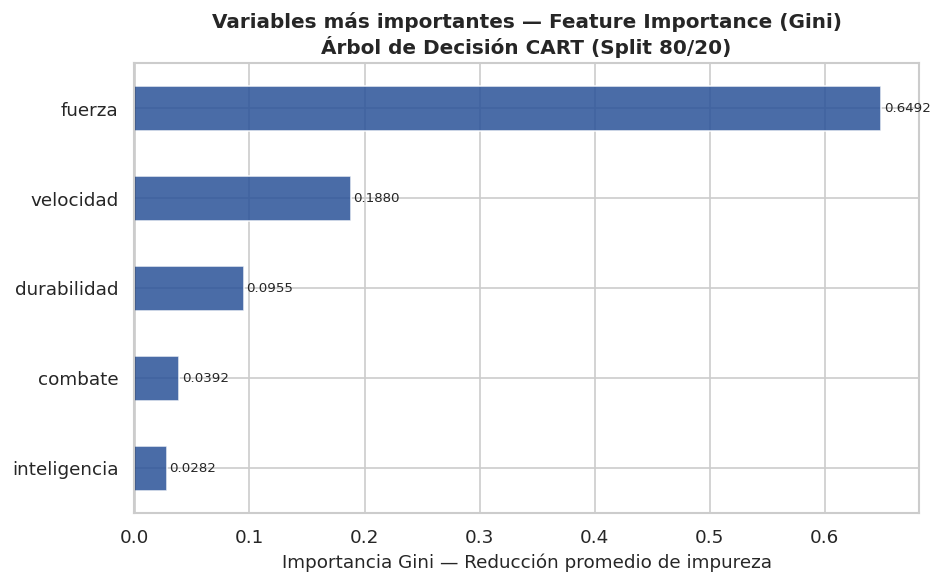

✅ Feature importance guardada en data/graficas/feature_importance_arbol_superheroes.png

📊 Suma de todas las importancias: 1.000000 (debe ser ≈ 1.0)

Variables más importantes:
fuerza          0.649152
velocidad       0.187998
durabilidad     0.095541
combate         0.039157
inteligencia    0.028151


In [11]:
# ── CELDA 11: Importancia de variables (Feature Importance Gini) ─────────────
modelo_ref = resultados[0]['modelo']   # Split 80/20

importancias = pd.Series(
    modelo_ref.feature_importances_,
    index=X.columns
)

importancias_ord = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

importancias_ord.plot(
    kind='barh',
    ax=ax,
    color='#2a5298',
    alpha=0.85
)

ax.set_xlabel(
    'Importancia Gini — Reducción promedio de impureza',
    fontsize=11
)

ax.set_title(
    'Variables más importantes — Feature Importance (Gini)\n'
    'Árbol de Decisión CART (Split 80/20)',
    fontsize=12,
    fontweight='bold'
)

ax.axvline(x=0, color='black', linewidth=0.8)

# Anotar valores
for patch in ax.patches:
    width = patch.get_width()
    if width > 0.001:
        ax.text(
            width + 0.002,
            patch.get_y() + patch.get_height() / 2,
            f'{width:.4f}',
            va='center',
            fontsize=8
        )

plt.tight_layout()
plt.savefig('../data/graficas/feature_importance_arbol_superheroes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature importance guardada en data/graficas/feature_importance_arbol_superheroes.png")
print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f} (debe ser ≈ 1.0)")

print(f"\nVariables más importantes:")
print(importancias.sort_values(ascending=False).to_string())

In [13]:
# ── CELDA 12: DataFrame resumen de métricas ──────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'], 4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'], 4),
    'F1-Score'       : round(r['f1'], 4),
    'ROC-AUC'        : round(r['roc_auc'], 4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 75)
print(f"{'TABLA FINAL DE MÉTRICAS':^75}")
print("=" * 75)

display(
    resumen.style
    .background_gradient(
        cmap='Greens',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    )
    .format(
        '{:.4f}',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    )
    .set_caption(
        "Árbol de Decisión CART — Clasificación Binaria: Superhéroe Poderoso / No Poderoso"
    )
)

print(f"\n📌 Mejor depth encontrado en la búsqueda: {mejor_depth}")

                          TABLA FINAL DE MÉTRICAS                          


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,584,147,0.8980,0.6286,0.9167,0.7458,0.9351
Split 60/40,438,293,0.9113,0.6719,0.8958,0.7679,0.9438
Split 70/30,511,220,0.9500,0.7778,0.9722,0.8642,0.9743



📌 Mejor depth encontrado en la búsqueda: 7
